# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty discourages the model from using very large coefficients just to perfectly fit the training data. Instead of chasing every small fluctuation which can be noise, the model is pushed to stay simpler and more stable. This helps prevent overfitting and improves how well the model handles new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization balances bias and variance. As the penalty increases, the model becomes simpler with lower variance, but higher bias. As the penalty decreases, the opposite happens. By adjusting the penalty, we can find the optimal spot that minimizes overall prediction error.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge (L2) shrinks coefficients toward zero but rarely makes them exactly zero. But, LASSO (L1) does feature selection and can make coefficients zero. So, LASSO is better when you think only a few features matter, while Ridge is better when many features contribute a little.

4. How do we typically scale variables for use in regularized regression? Why?

We usually standardize variables so that the mean = 0 and variance = 1. We do this because the penalty depends on the size of coefficients, and without scaling, variables with larger units would be unfairly penalized more. Scaling ensures all features are treated equally.

5. How is the penalty $\alpha$ typically selected?

Alpha is typically chosen using cross-validation. We want to optimize for data beyond just the training data so we want to minimize the validation error. 

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, we evaluate cross-validated MSE without the penalty term becase the goal is to measure how well the model predicts new data, and the penalty is just a training tool to control complexity. Including the penalty term would distort the actual prediction error.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.model_selection import cross_val_score

df = pd.read_csv("cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
# 2.1

df["Age"] = df["Make_Year"].max() - df["Make_Year"]

X_raw = df[["Mileage_Run", "Age"]]
y = df["Price"]

# (a) third degree polynomial expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# (b) standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

print("Feature names:")
print(feature_names)

Feature names:
['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [8]:
# 2.2

linreg = LinearRegression()
linreg.fit(X_scaled_df, y)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "linear_reg_coef": linreg.coef_
})

print(coef_df)

# interaction term
interaction_row = coef_df[coef_df["feature"] == "Mileage_Run Age"]
print("\nInteraction term:")
print(interaction_row)

             feature  linear_reg_coef
0        Mileage_Run    458071.119627
1                Age   -136698.072100
2      Mileage_Run^2    -91643.120024
3    Mileage_Run Age   -898405.751356
4              Age^2    113603.822348
5      Mileage_Run^3    -65144.896599
6  Mileage_Run^2 Age    229021.676556
7  Mileage_Run Age^2    368955.713359
8              Age^3    -84038.066146

Interaction term:
           feature  linear_reg_coef
3  Mileage_Run Age   -898405.751356


The sign is negative. 

In [9]:
# 2.3

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=1)
lasso_cv.fit(X_scaled_df, y)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 784.7599703514607


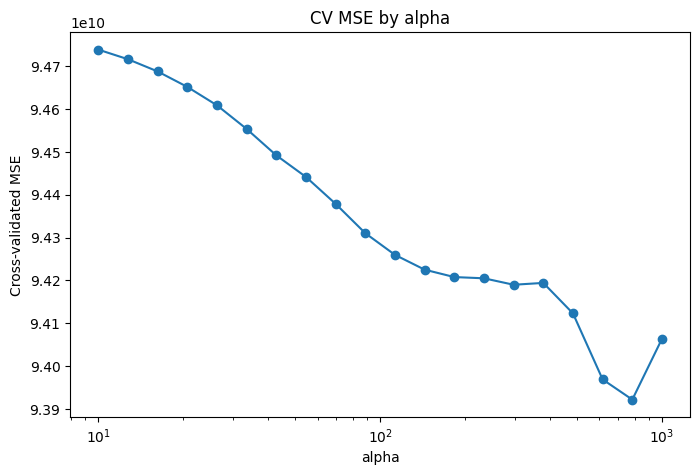

In [10]:
# 2.4 

mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE by alpha")
plt.show()

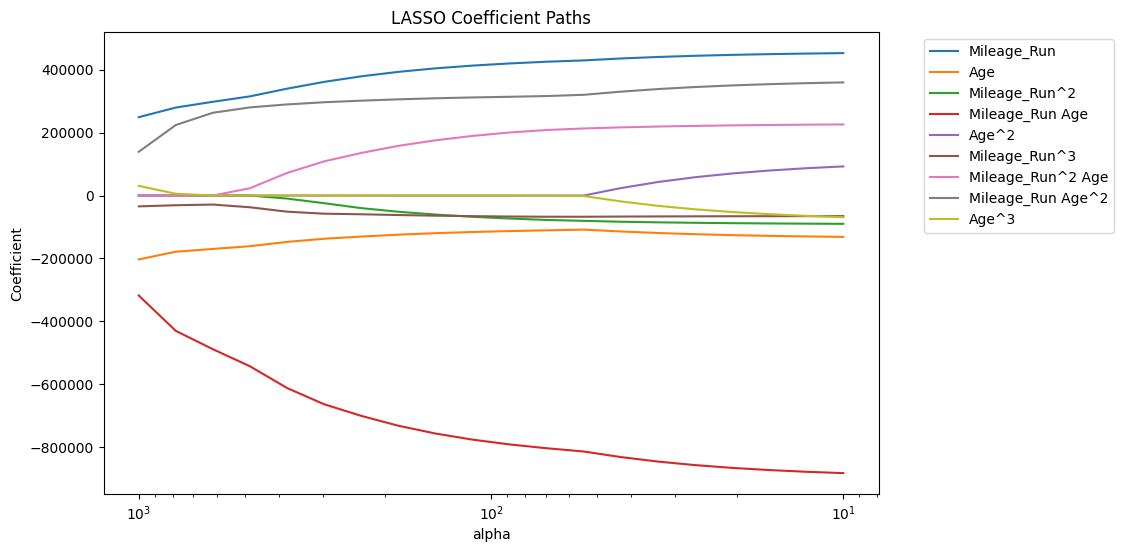

In [11]:
# 2.5

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled_df, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")
plt.gca().invert_xaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
# 2.6

lasso_best = Lasso(alpha=lasso_cv.alpha_, max_iter=100000)
lasso_best.fit(X_scaled_df, y)

lasso_coef_df = pd.DataFrame({
    "feature": feature_names,
    "lasso_coef": lasso_best.coef_
})

print(lasso_coef_df)

selected = lasso_coef_df[lasso_coef_df["lasso_coef"] != 0]
zeroed = lasso_coef_df[lasso_coef_df["lasso_coef"] == 0]

print("\nSelected features:")
print(selected["feature"].tolist())

prop_zero = len(zeroed) / len(lasso_coef_df)
print("\nProportion set to zero:", prop_zero)

             feature     lasso_coef
0        Mileage_Run  279901.144475
1                Age -178627.649418
2      Mileage_Run^2      -0.000000
3    Mileage_Run Age -430522.371167
4              Age^2      -0.000000
5      Mileage_Run^3  -30772.352392
6  Mileage_Run^2 Age       0.000000
7  Mileage_Run Age^2  224381.027339
8              Age^3    5666.626835

Selected features:
['Mileage_Run', 'Age', 'Mileage_Run Age', 'Mileage_Run^3', 'Mileage_Run Age^2', 'Age^3']

Proportion set to zero: 0.3333333333333333


In [ ]:
# 2.7

compare_df = coef_df.merge(lasso_coef_df, on="feature")
compare_df["abs_linear"] = compare_df["linear_reg_coef"].abs()
compare_df["abs_lasso"] = compare_df["lasso_coef"].abs()
compare_df["increased_magnitude"] = compare_df["abs_lasso"] > compare_df["abs_linear"]
compare_df["changed_sign"] = np.sign(compare_df["linear_reg_coef"]) != np.sign(compare_df["lasso_coef"])

print(compare_df[["feature", "linear_reg_coef", "lasso_coef", "increased_magnitude", "changed_sign"]])

             feature  linear_reg_coef     lasso_coef  increased_magnitude  \
0        Mileage_Run    458071.119627  279901.144475                False   
1                Age   -136698.072100 -178627.649418                 True   
2      Mileage_Run^2    -91643.120024      -0.000000                False   
3    Mileage_Run Age   -898405.751356 -430522.371167                False   
4              Age^2    113603.822348      -0.000000                False   
5      Mileage_Run^3    -65144.896599  -30772.352392                False   
6  Mileage_Run^2 Age    229021.676556       0.000000                False   
7  Mileage_Run Age^2    368955.713359  224381.027339                False   
8              Age^3    -84038.066146    5666.626835                False   

   changed_sign  
0         False  
1         False  
2          True  
3         False  
4          True  
5         False  
6          True  
7         False  
8          True  


Most coefficients decrease in magnitude when moving from linear regression to LASSO, which is expected due to regularization. The only coefficient that increases in magnitude is Age, which became slightly more negative. Several coefficients change sign, including Mileage_Run^2, Age^2, Mileage_Run^2 Age, and Age^3, some of these, however, are driven to exactly zero by LASSO. Overall, LASSO simplifies the model by shrinking coefficients and eliminating less important polynomial terms.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [15]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [17]:
# 3.1

cont_vars = ["age", "ejection_fraction", "serum_creatinine"]
X_cont = df[cont_vars]

# third-degree polynomial expansion
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

# z-score normalize
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

# put into dataframe
cont_feature_names = poly_cont.get_feature_names_out(cont_vars)
X_cont_df = pd.DataFrame(X_cont_scaled, columns=cont_feature_names)

dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
X_dummy = df[dummy_vars]

poly_dummy = PolynomialFeatures(
    degree=len(dummy_vars),
    include_bias=False,
    interaction_only=True
)
X_dummy_interactions = poly_dummy.fit_transform(X_dummy)

dummy_feature_names = poly_dummy.get_feature_names_out(dummy_vars)
X_dummy_df = pd.DataFrame(X_dummy_interactions, columns=dummy_feature_names)

X = pd.concat(
    [X_cont_df.reset_index(drop=True), X_dummy_df.reset_index(drop=True)],
    axis=1
)

In [ ]:
# 3.2

y = df["DEATH_EVENT"]

# linear regression
linreg = LinearRegression()
linreg.fit(X, y)

# get coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linreg.coef_
})

print(coef_df)

                                         feature  coefficient
0                                            age     1.619432
1                              ejection_fraction    -2.062277
2                               serum_creatinine    -0.757092
3                                          age^2    -3.717758
4                          age ejection_fraction    -0.800726
5                           age serum_creatinine     1.707056
6                            ejection_fraction^2     3.352956
7             ejection_fraction serum_creatinine     2.569764
8                             serum_creatinine^2    -2.640240
9                                          age^3     1.963124
10                       age^2 ejection_fraction     1.054408
11                        age^2 serum_creatinine    -0.679042
12                       age ejection_fraction^2    -0.066433
13        age ejection_fraction serum_creatinine    -1.626996
14                        age serum_creatinine^2     1.444075
15      

Some coefficient signs appear counterintuitive. For example, age has a positive coefficient, which suggests older patients are less likely to die, and higher-order terms like ejection_fraction² have signs that look different from their linear terms. This happens because the model includes many correlated polynomial and interaction features, causing the effects to be distributed across multiple terms and making the individual coefficients difficult to interpret.

The inclusion of higher-order powers and interactions helps resolve contradictions because it allows the model to capture nonlinear and joint relationships between variables. Instead of relying on a single linear effect, the model can represent more complex patterns, so the overall relationship still makes sense even there are contradictary coefficients. 

In [ ]:
# 3.3 

alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=1)
lasso_cv.fit(X, y)

print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.005736152510448681


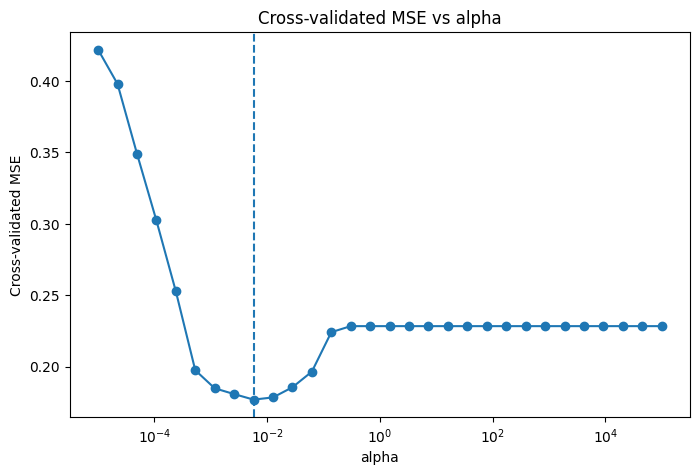

In [20]:
# 3.4 

mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')

plt.axvline(lasso_cv.alpha_, linestyle='--')

plt.show()

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.087e-03, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(


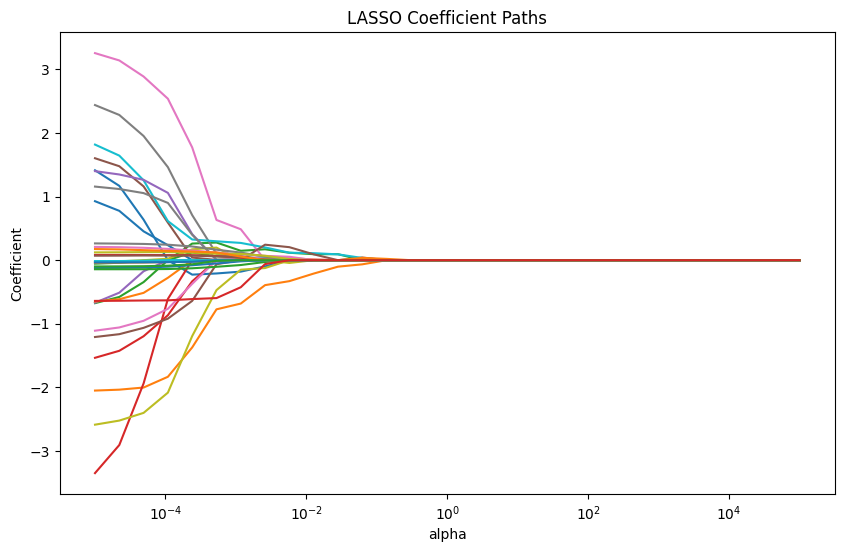

In [22]:
# 3.5
coef_paths = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X, y)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)

# plot
plt.figure(figsize=(10,6))

for i, feature in enumerate(X.columns):
    plt.plot(alphas, coef_paths[:, i], label=feature)

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient')
plt.title('LASSO Coefficient Paths')

plt.show()

In [29]:
#3.6

from sklearn.linear_model import LinearRegression, LassoCV, Lasso
import pandas as pd
import numpy as np

# linear regression
linreg = LinearRegression()
linreg.fit(X, y)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": linreg.coef_
})

# lasso
alphas = np.logspace(-4, 1, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=1)
lasso_cv.fit(X, y)

lasso_best = Lasso(alpha=lasso_cv.alpha_, max_iter=100000)
lasso_best.fit(X, y)

lasso_coef_df = pd.DataFrame({
    "feature": X.columns,
    "lasso_coef": lasso_best.coef_
})

# compare
compare_df = coef_df.merge(lasso_coef_df, on="feature")

print("Best alpha:", lasso_cv.alpha_)
print("Rows in compare_df:", len(compare_df))

selected = compare_df[compare_df["lasso_coef"] != 0]
zeroed = compare_df[compare_df["lasso_coef"] == 0]

print("\nSelected features:")
print(selected["feature"].tolist())

print("\nProportion set to zero:", len(zeroed) / len(compare_df))

print("\nComparison:")
print(compare_df[["feature", "coefficient", "lasso_coef"]])

Best alpha: 0.007880462815669913
Rows in compare_df: 34

Selected features:
['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'high_blood_pressure', 'diabetes high_blood_pressure']

Proportion set to zero: 0.7352941176470589

Comparison:
                                         feature  coefficient  lasso_coef
0                                            age     1.619432   -0.000000
1                              ejection_fraction    -2.062277   -0.293449
2                               serum_creatinine    -0.757092    0.108147
3                                          age^2    -3.717758    0.000000
4                          age ejection_fraction    -0.800726   -0.000000
5                           age serum_creatinine     1.707056    0.000000
6                            ejection_fraction^2     3.352956    0.000000
7             ejection_fraction serum_creatinine     2.569764    0.000000

The LASSO model ends up selecting a much smaller set of features, specifically: ejection_fraction, serum_creatinine, age³, ejection_fraction³, ejection_fraction² × serum_creatinine, serum_creatinine³, anaemia, high_blood_pressure, and diabetes × high_blood_pressure. Everything else gets shrunk down to zero, and overall about 73.5% of the coefficients are set to zero, which shows pretty strong feature selection.

Compared to the regular linear regression, most of the coefficients get smaller under LASSO, and a lot of them just drop out completely. There are also some sign changes — for example, serum_creatinine flips from negative to positive, which probably reflects how the original model was spreading effects across too many correlated terms.

The LASSO model definitely makes more sense. The linear model had a lot of weird or hard-to-interpret signs because it was trying to fit all these polynomial and interaction terms at once. LASSO simplifies things and keeps only the features that actually matter, so the results feel a lot more stable.

From a bias–variance perspective, the linear model has low bias but really high variance, which is why it ends up overfitting and giving unstable coefficients. LASSO adds a bit of bias by shrinking things, but it reduces variance a lot, which is why the final model is cleaner and more reliable.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

### Q4

**4.1**

$$
\min_{b_0, b_1} \; \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

**4.2**

Since the data is mean-centered, $\sum \tilde{x}_i = 0$ and $\sum \tilde{y}_i = 0$, so $b_0 = 0$.


$$
b_1 = \frac{\sum \tilde{x}_i \tilde{y}_i}{\sum \tilde{x}_i^2 + n\alpha}
$$


**4.3**

As $\alpha$ increases, the denominator increases, so $b_1$ approaches 0. This means ridge regression penalizes large coefficients and makes the model simpler.


**4.4**

With the LASSO penalty, the objective becomes:

$$
\frac{1}{n} \sum (\tilde{y}_i - b_1 \tilde{x}_i)^2 + \alpha |b_1|
$$

The challenge is that $|b_1|$ is not differentiable at 0, so we cannot use standard derivatives. When the relationship between $x$ and $y$ is weak relative to the penalty, it is optimal to set $b_1 = 0$. In this case, the penalty outweighs the benefit of including the variable, so LASSO sets the coefficient exactly to zero.